In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Importing the necessary packages required for the analysis
import pandas as pd
import numpy as np
import re
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Getting the dataset from the location
df = pd.read_csv("/content/drive/MyDrive/2024-2025(Even)/NLP/Corona_NLP_train.csv",encoding='latin-1')
#visulaizing the data contents in the dataset
#It gives first five rows of the given dataset
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


In [ ]:
#Checking for any null or missing values in the dataset
print(df.isnull().sum())

UserName            0
ScreenName          0
Location         8590
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64


In [ ]:
#Checking for any duplicate records in the dataset
print(df.duplicated().sum())

0


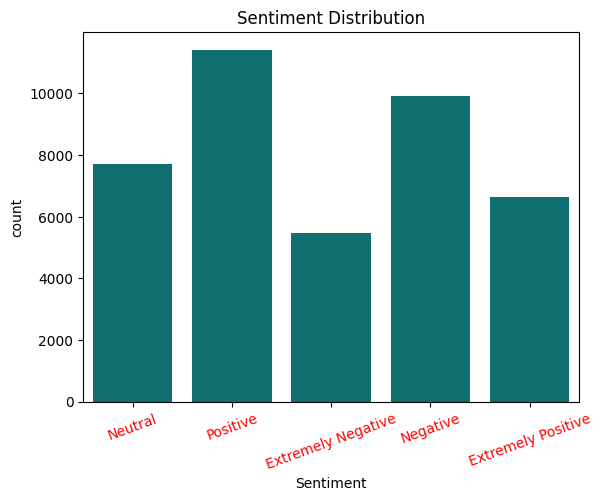

In [ ]:
#Understanding the data distribution
'''
Checking the sentimebt distribution
'''
sns.countplot(x=df['Sentiment'],color='teal')
plt.title("Sentiment Distribution")
plt.xticks(rotation=20,color='red')#Says how many degree the x label has to be rotated
plt.show()

In [ ]:
#Shows how many unique records each sentiment holds
print(df['Sentiment'].value_counts())


Sentiment
Positive              11422
Negative               9917
Neutral                7713
Extremely Positive     6624
Extremely Negative     5481
Name: count, dtype: int64


In [ ]:
#We will be downloading the libraries required
nltk.download('stopwords')
#it is the sentence tokenizer within the NLP toolkit(NLTK)
nltk.download('punkt_tab') # Download the punkt_tab resource



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()#initializing the stemmer

In [ ]:
#Creating a function for handling the text preprocessing
def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    words = word_tokenize(text)  # Tokenization
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    words = [stemmer.stem(word) for word in words]  # Stemming
    return " ".join(words)

In [ ]:
#Now we are going to apply the text preprocessing function
df["cleaned_text"] = df["OriginalTweet"].astype(str).apply(clean_text)


In [ ]:
#Displaying the cleared text
print(df[["OriginalTweet", "cleaned_text"]].head())


                                       OriginalTweet  \
0  @MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...   
1  advice Talk to your neighbours family to excha...   
2  Coronavirus Australia: Woolworths to give elde...   
3  My food stock is not the only one which is emp...   
4  Me, ready to go at supermarket during the #COV...   

                                        cleaned_text  
0  menyrbi philgahan chrisitv httpstcoifzfanpa ht...  
1  advic talk neighbour famili exchang phone numb...  
2  coronaviru australia woolworth give elderli di...  
3  food stock one empti pleas dont panic enough f...  
4  readi go supermarket covid outbreak im paranoi...  


In [ ]:
#convert the text into numerical representation
vectorizer=TfidfVectorizer(max_features=5000)  #My food stock is not the only one
#tf(not)1/8=0.125-->Term frequency
#idf=>log(5/1)-log(5)==>0.69
#tf-idf(not)==>tf(not)*idf(not)--->0.125*0.69==>0.086
X = vectorizer.fit_transform(df['cleaned_text'])  # Transform text data
y = df['Sentiment']  # Target labels
#Encode the label values
encoder=LabelEncoder()
y=encoder.fit_transform(y)

In [ ]:
#Split the training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#Train the navie bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)

# Evaluate
print("Naïve Bayes Model Performance")
print(accuracy_score(y_test, y_pred_nb))



Naïve Bayes Model Performance
0.4607628765792031


In [ ]:
#Train the SVM model
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluate
print("SVM Model Performance")
print(accuracy_score(y_test, y_pred_svm))



SVM Model Performance
0.6292517006802721
